# Zomato (Bangalore) Restaurant & Review Data Analysis
### Alfido Tech — Data Internship · Task 1
**Author:** Rudra

**Goal:** Analyse restaurant & review data to extract insights on ratings, cuisines, location
preferences and the factors affecting ratings — then deliver 5 platform recommendations.

**Dataset:** [Kaggle · bhanupratapbiswas/zomato](https://www.kaggle.com/datasets/bhanupratapbiswas/zomato)
— the **Bangalore** restaurants table (`zomato.csv`, ~56k rows, 13 columns).

> This is a **single-city (Bengaluru)** dataset, so *location* means *neighbourhood* and all prices are
> already in one currency (INR) — no currency conversion is needed. The file also ships with a
> data-quality quirk: ~8% of rows are corrupted by un-escaped newlines in text fields; we repair this
> in the cleaning step.

**Getting the data:** place `zomato.csv` next to this notebook, or:
```python
# !pip install kaggle -q
# !kaggle datasets download -d bhanupratapbiswas/zomato --unzip
```

In [1]:
# 0. Setup
!pip install pandas numpy matplotlib seaborn wordcloud reportlab -q

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

ZRED, INK, ACCENT = "#CB202D", "#1f2933", "#2563eb"
PALETTE = ["#CB202D", "#F25C54", "#F4A259", "#5B8E7D", "#2563eb", "#7C3AED", "#0EA5E9"]
os.makedirs("figures", exist_ok=True)
DATA_PATH = "zomato.csv"

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Load

In [2]:
def load_data(path=DATA_PATH):
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            df = pd.read_csv(path, encoding=enc, engine="python")  # python engine handles quoted newlines
            print(f"Loaded {path}: {df.shape[0]:,} raw rows x {df.shape[1]} cols (encoding={enc})")
            return df
        except Exception:
            continue
    raise FileNotFoundError(path)

raw = load_data()
raw.head(3)

Loaded zomato.csv: 56,252 raw rows x 13 cols (encoding=utf-8)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet


## 2. Data cleaning
Repair corrupted rows, parse `rate` → numeric, clean cost, split multi-value text fields, de-duplicate.

In [3]:
def parse_rate(x):
    """'4.1/5' or '3.9 /5' -> 4.1 ; 'NEW','-',NaN -> NaN (unrated)."""
    if pd.isna(x): return np.nan
    if "NEW" in str(x).upper(): return np.nan
    m = re.search(r"(\d\.\d|\d)", str(x))
    if m:
        v = float(m.group(1));  return v if 0 <= v <= 5 else np.nan
    return np.nan


def clean(df):
    df = df.copy(); df.columns = [c.strip() for c in df.columns]

    # integrity repair: corrupted export rows have garbage in strict Yes/No columns
    before = len(df)
    df = df[df["online_order"].isin(["Yes","No"]) & df["book_table"].isin(["Yes","No"])].copy()
    print(f"Dropped {before-len(df):,} corrupted rows -> {len(df):,} clean listings")

    df["rating"]  = df["rate"].apply(parse_rate)
    df["is_new"]  = df["rate"].astype(str).str.upper().str.contains("NEW")
    df["is_rated"] = df["rating"].notna()
    df["votes"]   = pd.to_numeric(df["votes"], errors="coerce").fillna(0).astype(int)
    df["cost_for_two"] = pd.to_numeric(
        df["approx_cost(for two people)"].astype(str).str.replace(",","",regex=False), errors="coerce")

    for c in ["online_order","book_table","location","rest_type","listed_in(type)","cuisines"]:
        df[c] = df[c].astype("string").str.strip()
    df["primary_cuisine"]   = df["cuisines"].str.split(",").str[0].str.strip()
    df["num_cuisines"]      = df["cuisines"].apply(lambda s: 0 if pd.isna(s) else len([x for x in str(s).split(",") if x.strip()]))
    df["primary_rest_type"] = df["rest_type"].str.split(",").str[0].str.strip()

    # unique-restaurant view (each venue is listed once per service type)
    df["restaurant_key"] = df["name"].astype(str).str.lower().str.strip()+"|"+df["address"].astype(str).str.lower().str.strip()
    du = df.drop_duplicates(subset="restaurant_key").copy()
    print(f"Unique restaurants: {len(du):,} | rated: {df['is_rated'].mean()*100:.1f}% | NEW: {df['is_new'].sum():,}")
    return df, du

df, du = clean(raw)
du[["name","location","primary_cuisine","cost_for_two","rating","votes","online_order","book_table"]].head()

Dropped 4,535 corrupted rows -> 51,717 clean listings


Unique restaurants: 12,494 | rated: 80.6% | NEW: 2,208


,name,location,primary_cuisine,cost_for_two,rating,votes,online_order,book_table
0,Jalsa,Banashankari,North Indian,800.0,4.1,775,Yes,Yes
1,Spice Elephant,Banashankari,Chinese,800.0,4.1,787,Yes,No
2,San Churro Cafe,Banashankari,Cafe,800.0,3.8,918,Yes,No
3,Addhuri Udupi Bhojana,Banashankari,South Indian,300.0,3.7,88,No,No
4,Grand Village,Basavanagudi,North Indian,600.0,3.8,166,No,No


In [4]:
# Data-quality snapshot (unique restaurants)
display(du[["rating","votes","cost_for_two","num_cuisines"]].describe().T.round(2))
print("Missing (unique venues):")
print(du[["rating","cost_for_two","primary_cuisine"]].isna().sum())

,count,mean,std,min,25%,50%,75%,max
rating,9313.0,3.63,0.43,1.8,3.3,3.7,3.9,4.9
votes,12494.0,180.75,591.82,0.0,0.0,24.0,120.0,16345.0
cost_for_two,12435.0,487.25,390.90,40.0,250.0,400.0,600.0,6000.0
num_cuisines,12494.0,2.31,1.21,0.0,1.0,2.0,3.0,8.0


Missing (unique venues):
rating             3181
cost_for_two         59
primary_cuisine      19
dtype: int64


## 3. Ratings landscape

Mean rating: 3.63 | unrated: 25.5%


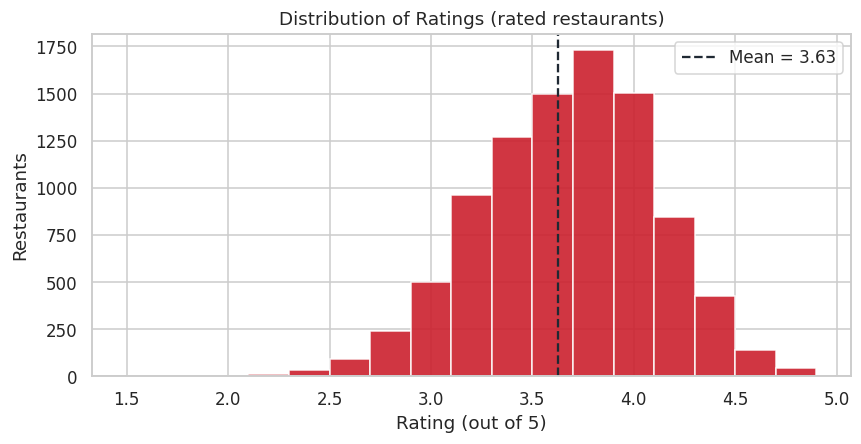

In [5]:
rated = du[du["is_rated"]]
print(f"Mean rating: {rated['rating'].mean():.2f} | unrated: {(~du['is_rated']).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8,4.2))
ax.hist(rated["rating"], bins=np.arange(1.5,5.05,0.2), color=ZRED, edgecolor="white", alpha=.9)
ax.axvline(rated["rating"].mean(), color=INK, ls="--", lw=1.5, label=f"Mean = {rated['rating'].mean():.2f}")
ax.set(title="Distribution of Ratings (rated restaurants)", xlabel="Rating (out of 5)", ylabel="Restaurants"); ax.legend()
plt.tight_layout(); plt.savefig("figures/01_rating_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Location hotspots (Bangalore neighbourhoods)

location
Whitefield           885
Electronic City      730
BTM                  727
HSR                  705
Marathahalli         686
Indiranagar          531
JP Nagar             523
Bannerghatta Road    474
Name: count, dtype: Int64


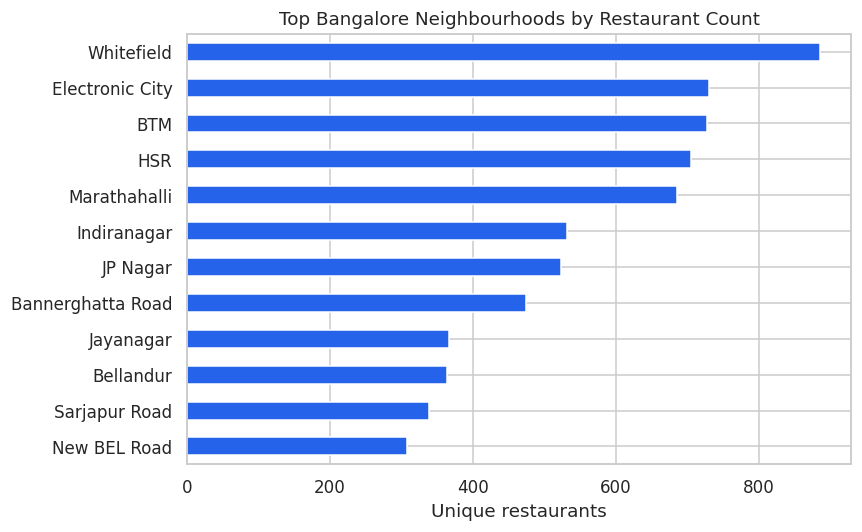

In [6]:
top_loc = du["location"].value_counts().head(12)
print(top_loc.head(8))

fig, ax = plt.subplots(figsize=(8,5))
top_loc.sort_values().plot(kind="barh", color=ACCENT, ax=ax)
ax.set(title="Top Bangalore Neighbourhoods by Restaurant Count", xlabel="Unique restaurants", ylabel="")
plt.tight_layout(); plt.savefig("figures/02_top_locations.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Cuisine & dish analysis

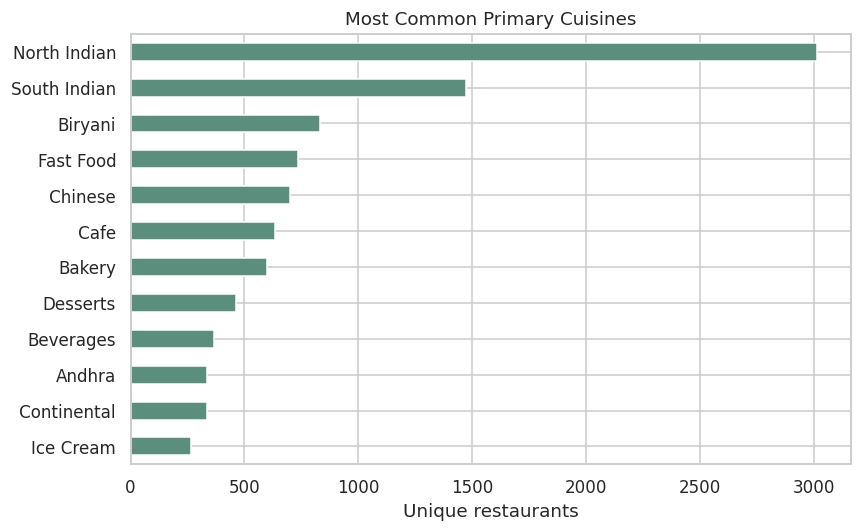

In [7]:
top_cuisines = du["primary_cuisine"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(8,5))
top_cuisines.sort_values().plot(kind="barh", color=PALETTE[3], ax=ax)
ax.set(title="Most Common Primary Cuisines", xlabel="Unique restaurants", ylabel="")
plt.tight_layout(); plt.savefig("figures/03_top_cuisines.png", dpi=150, bbox_inches="tight"); plt.show()

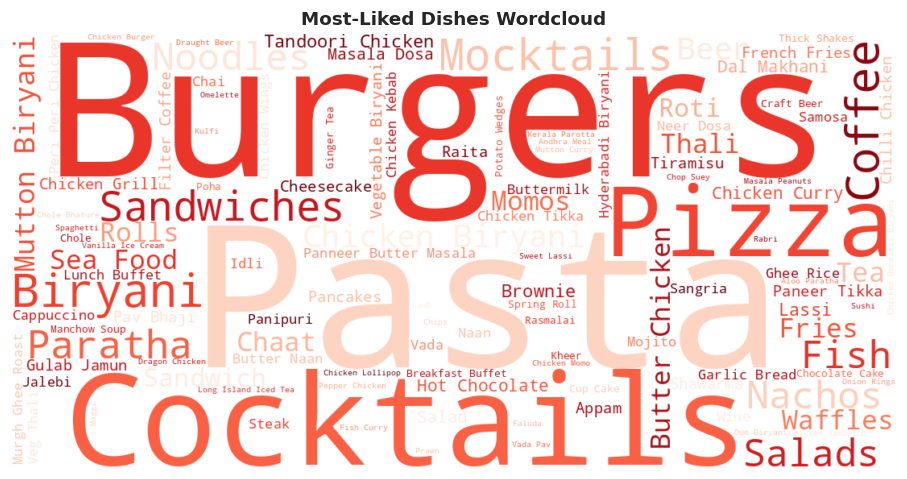

In [8]:
# Most-liked dishes wordcloud (review-derived highlights)
dishes = df["dish_liked"].dropna().str.split(",").explode().str.strip()
dishes = dishes[dishes.str.len() > 1]
wc = WordCloud(width=1100, height=540, background_color="white", colormap="Reds",
               prefer_horizontal=.95, max_words=120).generate_from_frequencies(dishes.value_counts().to_dict())
fig, ax = plt.subplots(figsize=(9,4.5)); ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
ax.set_title("Most-Liked Dishes Wordcloud", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/08_dish_wordcloud.png", dpi=150, bbox_inches="tight"); plt.show()

,avg_rating,count
primary_cuisine,,
Asian,4.11,58
American,4.03,70
Continental,3.89,284
Mexican,3.87,48
Finger Food,3.84,92
Italian,3.83,116
Desserts,3.82,352
Seafood,3.79,69
Cafe,3.77,565


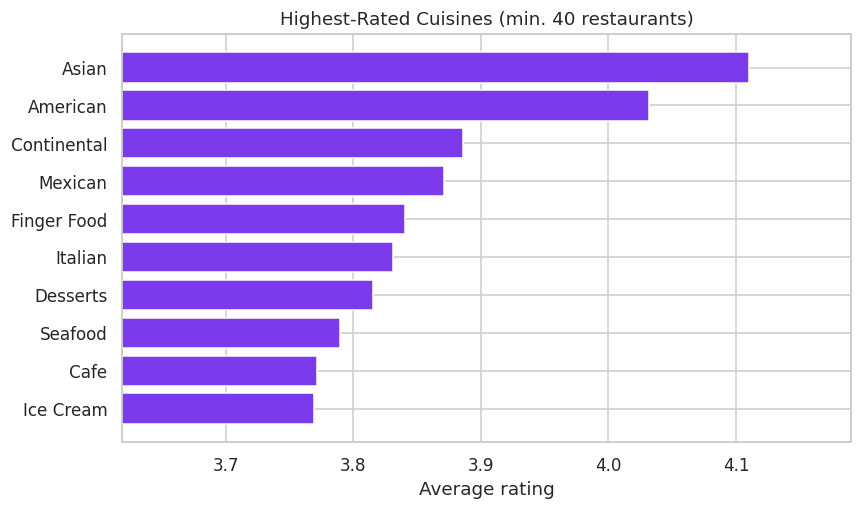

In [9]:
# Cuisine QUALITY (min 40 venues)
cz = (rated.groupby("primary_cuisine").agg(avg_rating=("rating","mean"), count=("rating","size")))
cz = cz[cz["count"]>=40].sort_values("avg_rating", ascending=False)
display(cz.head(10).round(2))

fig, ax = plt.subplots(figsize=(8,4.8))
top = cz.head(10).sort_values("avg_rating")
ax.barh(top.index, top["avg_rating"], color=PALETTE[5]); ax.set_xlim(top["avg_rating"].min()-.15, top["avg_rating"].max()+.08)
ax.set(title="Highest-Rated Cuisines (min. 40 restaurants)", xlabel="Average rating")
plt.tight_layout(); plt.savefig("figures/04_cuisine_vs_rating.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Price, service & what drives ratings

cost_band
Budget     3.553
Mid        3.542
Premium    3.563
Luxury     3.794
Name: rating, dtype: float64


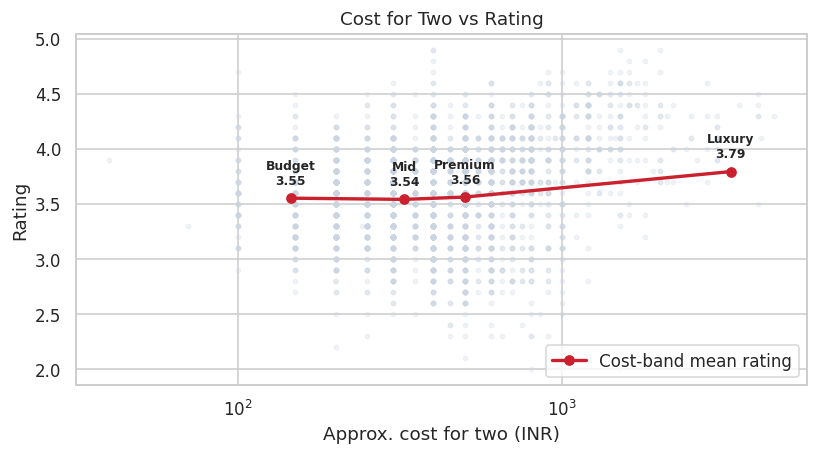

In [10]:
# Cost vs rating (band means)
duc = du.copy()
duc["cost_band"] = pd.qcut(duc["cost_for_two"].rank(method="first"), 4, labels=["Budget","Mid","Premium","Luxury"])
cb = duc[duc["is_rated"]].groupby("cost_band")["rating"].mean().round(3)
edges = duc.groupby("cost_band")["cost_for_two"].agg(["min","max"])
print(cb)

fig, ax = plt.subplots(figsize=(7.6,4.3))
s = rated.sample(min(3000,len(rated)), random_state=1)
ax.scatter(s["cost_for_two"], s["rating"], s=8, alpha=.25, color="#cbd5e1")
xs = [(edges.loc[b,"min"]+edges.loc[b,"max"])/2 for b in cb.index]
ax.plot(xs, cb.values, marker="o", color=ZRED, lw=2.2, label="Cost-band mean rating")
for x,y,b in zip(xs, cb.values, cb.index):
    ax.annotate(f"{b}\n{y:.2f}", (x,y), textcoords="offset points", xytext=(0,9), ha="center", fontsize=8, fontweight="bold")
ax.set(title="Cost for Two vs Rating", xlabel="Approx. cost for two (INR)", ylabel="Rating"); ax.set_xscale("log"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig("figures/05_cost_vs_rating.png", dpi=150, bbox_inches="tight"); plt.show()

online_order:
 online_order
No     3.589
Yes    3.649
Name: rating, dtype: float64 
book_table:
 book_table
No     3.572
Yes    4.115
Name: rating, dtype: float64


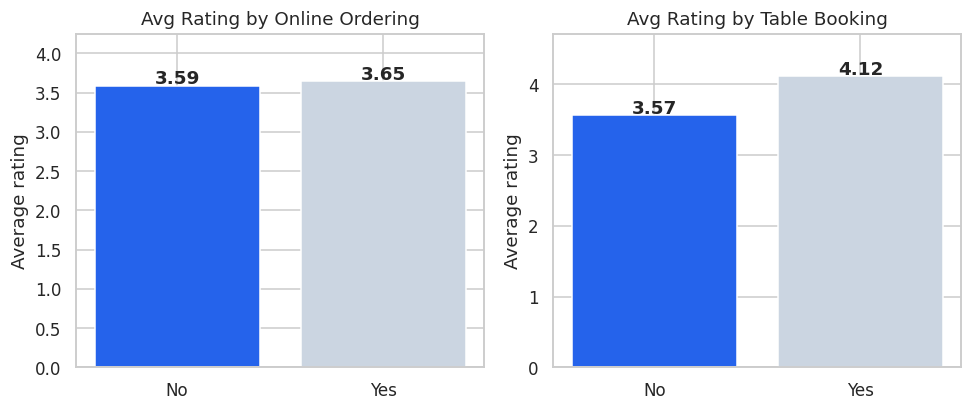

In [11]:
# Service options vs rating
oo = rated.groupby("online_order")["rating"].mean().round(3)
bt = rated.groupby("book_table")["rating"].mean().round(3)
print("online_order:\n", oo, "\nbook_table:\n", bt)

fig, axes = plt.subplots(1,2, figsize=(9,3.9))
for ax,d,t in [(axes[0],oo,"Online Ordering"),(axes[1],bt,"Table Booking")]:
    ax.bar(d.index.astype(str), d.values, color=[PALETTE[4],"#cbd5e1"])
    for i,v in enumerate(d.values): ax.text(i, v+.02, f"{v:.2f}", ha="center", fontweight="bold")
    ax.set(title=f"Avg Rating by {t}", ylabel="Average rating", ylim=(0,max(d.values)+.6))
plt.tight_layout(); plt.savefig("figures/09_service_vs_rating.png", dpi=150, bbox_inches="tight"); plt.show()

,avg_rating,count
primary_rest_type,,
Fine Dining,4.14,91
Pub,4.05,87
Lounge,3.87,74
Bar,3.86,139
Dessert Parlor,3.81,529
Cafe,3.77,569
Casual Dining,3.71,2246
Beverage Shop,3.66,279


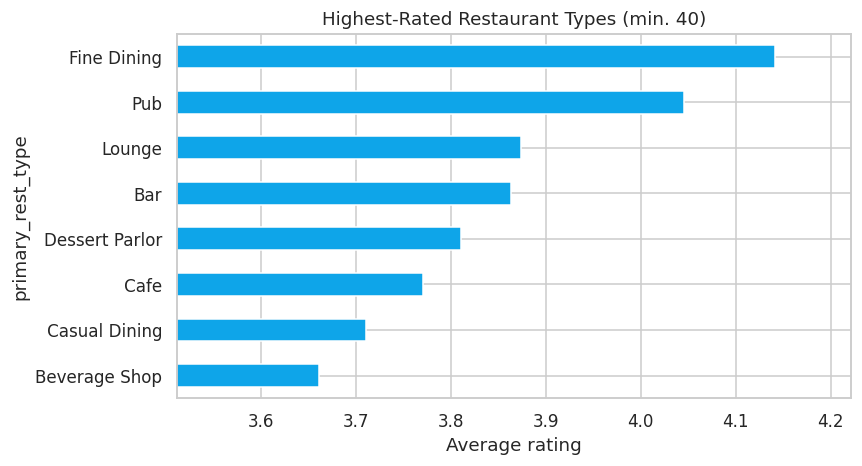

In [12]:
# Restaurant type quality (min 40)
rt = (rated.groupby("primary_rest_type").agg(avg_rating=("rating","mean"), count=("rating","size")))
rt = rt[rt["count"]>=40].sort_values("avg_rating", ascending=False).head(8)
display(rt.round(2))
fig, ax = plt.subplots(figsize=(8,4.4))
rt.sort_values("avg_rating")["avg_rating"].plot(kind="barh", color=PALETTE[6], ax=ax)
ax.set_xlim(rt["avg_rating"].min()-.15, rt["avg_rating"].max()+.08)
ax.set(title="Highest-Rated Restaurant Types (min. 40)", xlabel="Average rating")
plt.tight_layout(); plt.savefig("figures/10_resttype_vs_rating.png", dpi=150, bbox_inches="tight"); plt.show()

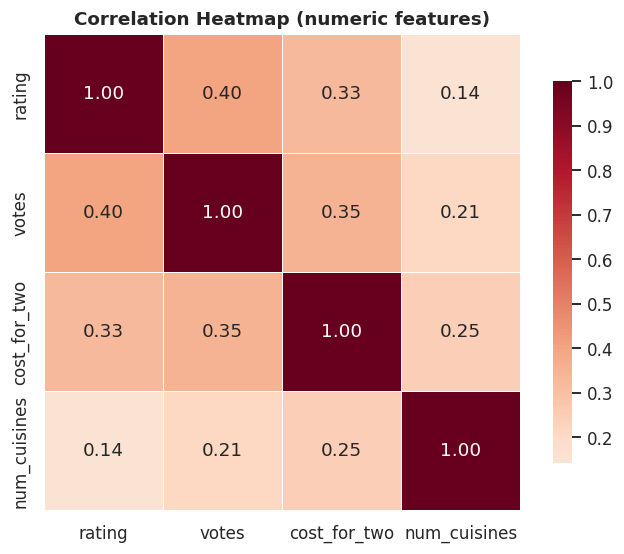

rating~votes: 0.399 | rating~cost: 0.327


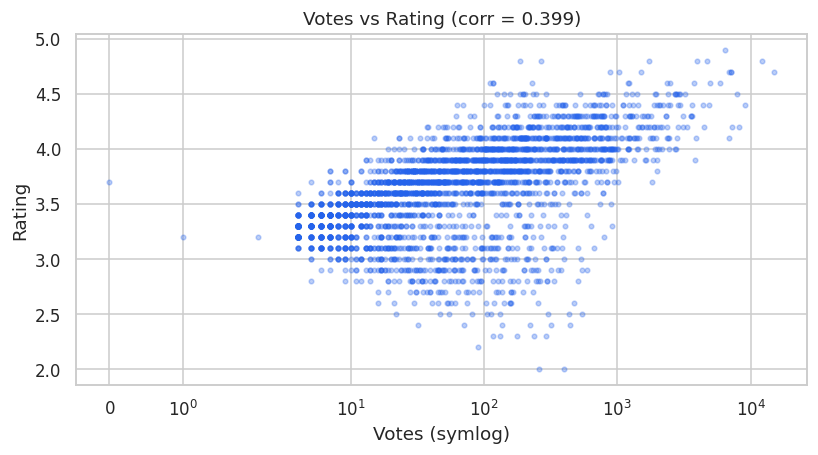

In [13]:
# Correlation heatmap + votes scatter
corr = du[["rating","votes","cost_for_two","num_cuisines"]].corr()
fig, ax = plt.subplots(figsize=(6.6,5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":.8}, linewidths=.5, ax=ax)
ax.set_title("Correlation Heatmap (numeric features)", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/06_correlation_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"rating~votes: {du['rating'].corr(du['votes']):.3f} | rating~cost: {du['rating'].corr(du['cost_for_two']):.3f}")

fig, ax = plt.subplots(figsize=(7.6,4.3))
s = rated.sample(min(3000,len(rated)), random_state=2)
ax.scatter(s["votes"], s["rating"], s=9, alpha=.3, color=ACCENT); ax.set_xscale("symlog")
ax.set(title=f"Votes vs Rating (corr = {du['rating'].corr(du['votes']):.3f})", xlabel="Votes (symlog)", ylabel="Rating")
plt.tight_layout(); plt.savefig("figures/07_votes_vs_rating.png", dpi=150, bbox_inches="tight"); plt.show()

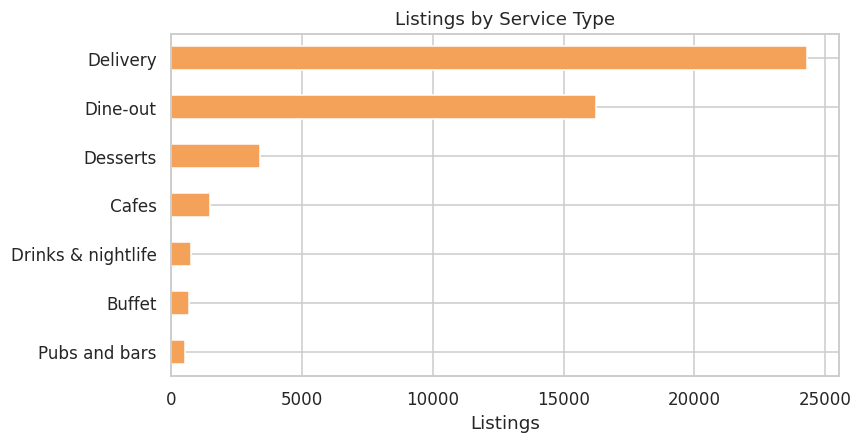

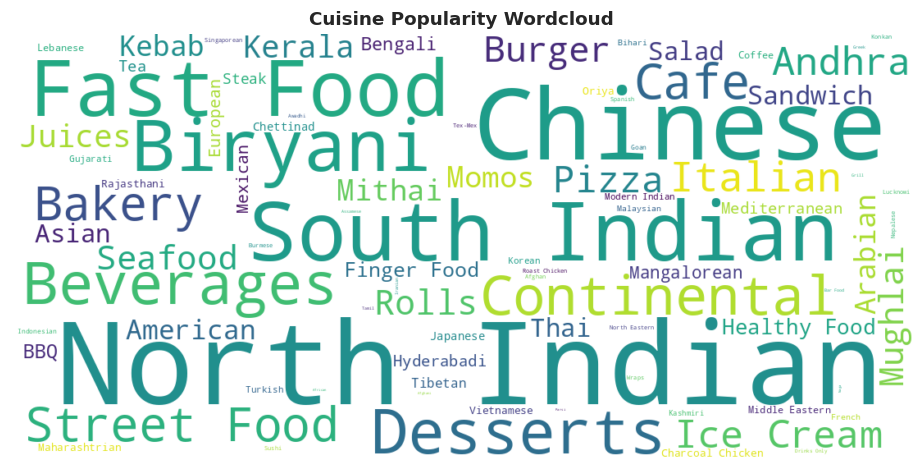

In [14]:
# Service-type mix + cuisine wordcloud
fig, ax = plt.subplots(figsize=(8,4.2))
df["listed_in(type)"].value_counts().sort_values().plot(kind="barh", color=PALETTE[2], ax=ax)
ax.set(title="Listings by Service Type", xlabel="Listings", ylabel="")
plt.tight_layout(); plt.savefig("figures/11_service_mix.png", dpi=150, bbox_inches="tight"); plt.show()

cf = du["cuisines"].dropna().str.split(",").explode().str.strip()
cf = cf[cf.str.len()>1].value_counts().to_dict()
wc2 = WordCloud(width=1100, height=520, background_color="white", colormap="viridis", prefer_horizontal=.95).generate_from_frequencies(cf)
fig, ax = plt.subplots(figsize=(9,4.4)); ax.imshow(wc2, interpolation="bilinear"); ax.axis("off")
ax.set_title("Cuisine Popularity Wordcloud", fontweight="bold")
plt.tight_layout(); plt.savefig("figures/08b_cuisine_wordcloud.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Key findings & 5 recommendations

**Findings**
1. ~26% of venues are **unrated** (incl. ~2.2k NEW restaurants); rated venues cluster tightly around **3.6/5**.
2. Supply concentrates in **tech-corridor neighbourhoods** — Whitefield, Electronic City, BTM, HSR.
3. **Popularity ≠ quality**: North Indian leads by volume, but Asian / American / Continental rate highest.
4. **Table booking is the strongest rating signal** (~4.1 vs ~3.6); price barely matters until the luxury tier.
5. **Votes** are the strongest numeric correlate of rating — engagement, not price, tracks perceived quality.

**Recommendations for an Alfido-Tech-style platform**
1. **Review-activation programme** — one-tap ratings + NEW-restaurant boost to close the unrated gap.
2. **Promote table-booking** as a first-class feature & filter — it tracks the best-rated experiences.
3. **Feature high-rated, under-supplied cuisines** (Asian/Continental) to differentiate discovery.
4. **Dish-led & neighbourhood content** ("best biryani near you", area spotlights) for engagement.
5. **Expand methodically beyond the IT-belt core** using the dense-market referral playbook.

## 8. Generate the PDF report

In [15]:
# Regenerate the polished PDF from the current data (needs build_report.py + pipeline.py in the repo).
import subprocess, sys
try:
    out = subprocess.run([sys.executable, "build_report.py"], capture_output=True, text=True, timeout=600)
    print(out.stdout or out.stderr)
    print("PDF ready: Zomato_Analysis_Report.pdf" if os.path.exists("Zomato_Analysis_Report.pdf") else "see repo for build_report.py")
except FileNotFoundError:
    print("build_report.py not present — analysis above is complete; use the repo builder to render the PDF.")

[load] zomato.csv: 56,252 raw rows x 13 cols (encoding=utf-8)
[pdf] wrote Zomato_Analysis_Report.pdf

PDF ready: Zomato_Analysis_Report.pdf
